# Keras - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

This is a copy of UCI ML Breast Cancer Wisconsin (Diagnostic) datasets.
https://goo.gl/U2Uwz2

Features are computed from a digitized image of a fine needle
aspirate (FNA) of a breast mass.  They describe
characteristics of the cell nuclei present in the image.

Separating plane described above was obtained using
Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree
Construction Via Linear Programming." Proceedings of the 4th
Midwest Artificial Intelligence and Cognitive Science Society,
pp. 97-101, 1992], a classification method which uses linear
programming to construct a decision tree.  Relevant features
were selected using an exhaustive search in the space of 1-4
features and 1-3 separating planes.

The actual linear program used to obtain the separating plane
in the 3-dimensional space is that described in:
[K. P. Bennett and O. L. Mangasarian: "Robust Linear
Programming Discrimination of Two Linearly Inseparable Sets",
Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:

ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

.. topic:: References

   - W.N. Street, W.H. Wolberg and O.L. Mangasarian. Nuclear feature extraction 
     for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on 
     Electronic Imaging: Science and Technology, volume 1905, pages 861-870,
     San Jose, CA, 1993.
   - O.L. Mangasarian, W.N. Street and W.H. Wolberg. Breast cancer diagnosis and 
     prognosis via linear programming. Operations Research, 43(4), pages 570-577, 
     July-August 1995.
   - W.H. Wolberg, W.N. Street, and O.L. Mangasarian. Machine learning techniques
     to diagnose breast cancer from fine-needle aspirates. Cancer Letters 77 (1994) 
     163-171.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("D:/5 month Learning/Python for Data Science/TensorFlow_FILES/TensorFlow_FILES/DATA/cancer_classification.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

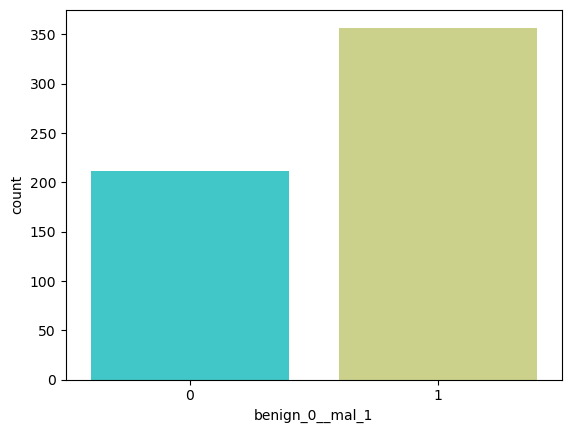

In [9]:
#checking if the data is having imbalanced class
sns.countplot(x = 'benign_0__mal_1',hue='benign_0__mal_1', data=df, palette="rainbow", legend=False)

<Axes: >

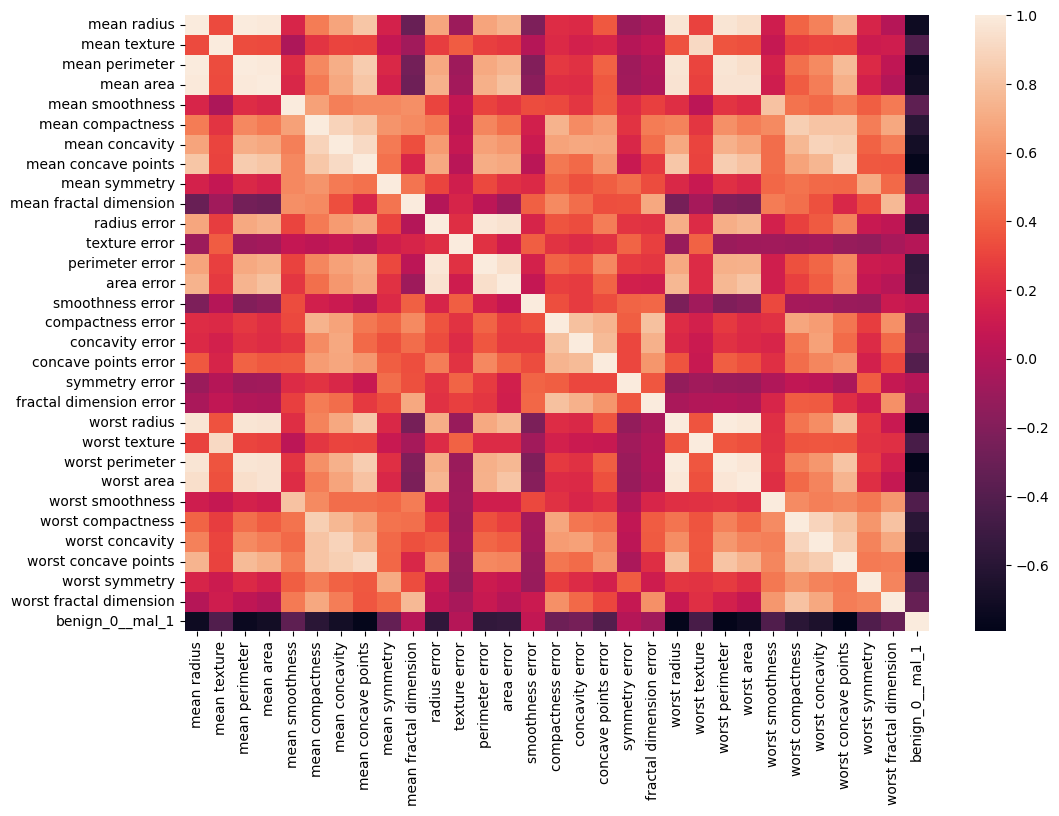

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr())

In [13]:
df.corr()['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

<Axes: >

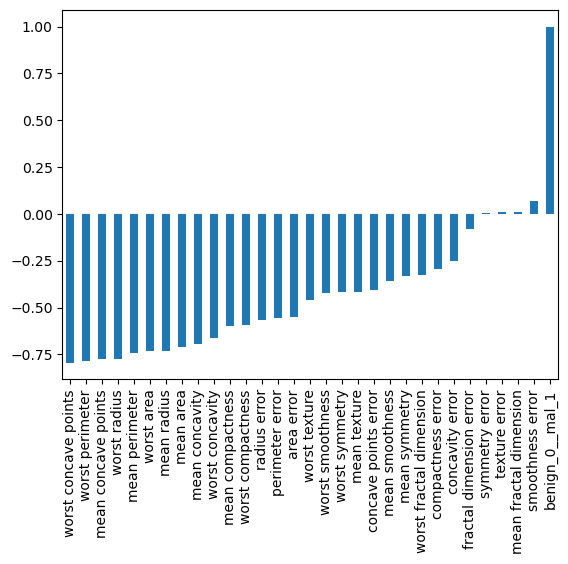

In [17]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

seems like most of the features are negatively correlated

<Axes: >

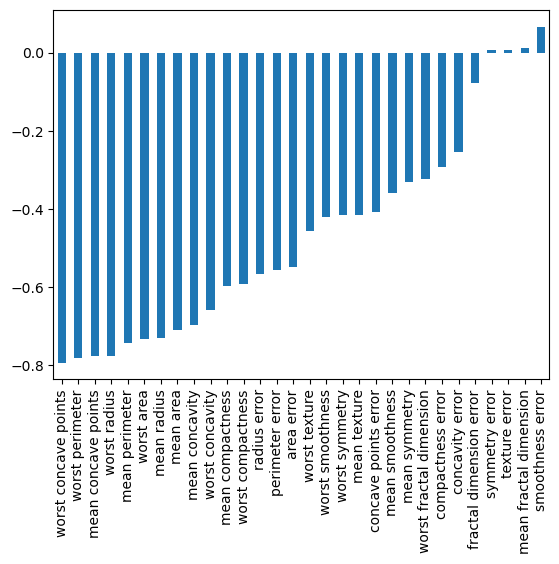

In [19]:
#excluding the last row
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar') 

## Train Test Split

In [20]:
X = df.drop('benign_0__mal_1',axis=1).values
y = df['benign_0__mal_1'].values

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=101)



## Scaling Data

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
scaler = MinMaxScaler()

In [26]:
scaler.fit(X_train)

MinMaxScaler()

In [27]:
X_train = scaler.transform(X_train)

In [28]:
X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

In [30]:
#checking the shape to match the number of neurons 
X_train.shape

(426, 30)

In [32]:
model = Sequential()

model.add(Dense(units=30, activation= 'relu'))

model.add(Dense(units=15, activation= 'relu'))

#last layer and its a classificaion task
model.add(Dense(units=1,activation='sigmoid'))

model.compile(loss= 'binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [34]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6591 - val_loss: 0.6471
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6289 - val_loss: 0.6183
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5973 - val_loss: 0.5857
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5598 - val_loss: 0.5401
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5087 - val_loss: 0.4870
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4590 - val_loss: 0.4325
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4071 - val_loss: 0.3820
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3599 - val_loss: 0.3406
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3229 - val_loss: 0.3014
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2922 - val_loss: 0.2733
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2624 - val_loss: 0.2409
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [35]:
model.history.history

{'loss': [0.6590791344642639,
  0.6289426684379578,
  0.5972989797592163,
  0.5598389506340027,
  0.5086636543273926,
  0.4589953124523163,
  0.40713897347450256,
  0.3599187731742859,
  0.3228868544101715,
  0.2921876311302185,
  0.2623772919178009,
  0.23993870615959167,
  0.21966645121574402,
  0.20322567224502563,
  0.19000114500522614,
  0.18030448257923126,
  0.16792312264442444,
  0.159155011177063,
  0.15031111240386963,
  0.14129884541034698,
  0.13365505635738373,
  0.1264665126800537,
  0.12393580377101898,
  0.11479147523641586,
  0.11225718259811401,
  0.10956478863954544,
  0.10503467172384262,
  0.09912624955177307,
  0.09291928261518478,
  0.09068261086940765,
  0.08929520100355148,
  0.08998628705739975,
  0.0830913856625557,
  0.08105190843343735,
  0.08015888184309006,
  0.0764857605099678,
  0.07748359441757202,
  0.08143797516822815,
  0.074423648416996,
  0.0729016587138176,
  0.06935001909732819,
  0.06937359273433685,
  0.06797362864017487,
  0.06690835952758789

In [36]:
model_loss = pd.DataFrame(model.history.history)

In [37]:
model_loss

,loss,val_loss
0,0.659079,0.647065
1,0.628943,0.618285
2,0.597299,0.585715
3,0.559839,0.540134
4,0.508664,0.487002
...,...,...
595,0.009581,0.233910
596,0.010203,0.232850
597,0.009665,0.244550
598,0.009343,0.232798


<Axes: >

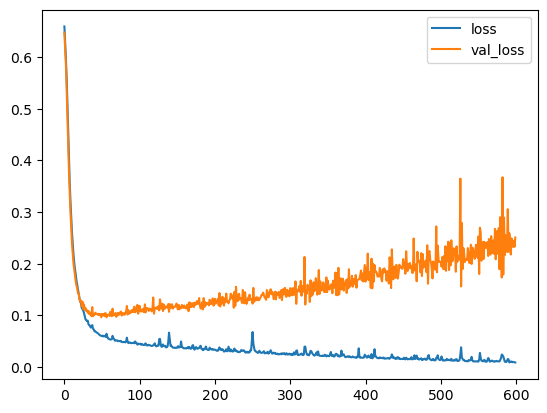

In [38]:
model_loss.plot()

while trainng for long time the training loss is decreasing , meanwhile the validation loss is increasing , which indicates the overfitting case.

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [39]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [42]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks = [early_stop]
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.6761 - val_loss: 0.6626
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6545 - val_loss: 0.6429
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6341 - val_loss: 0.6202
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6123 - val_loss: 0.5961
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5864 - val_loss: 0.5674
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5564 - val_loss: 0.5304
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5168 - val_loss: 0.4837
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4736 - val_loss: 0.4381
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4274 - val_loss: 0.3882
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3796 - val_loss: 0.3382
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3397 - val_loss: 0.2992
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

<Axes: >

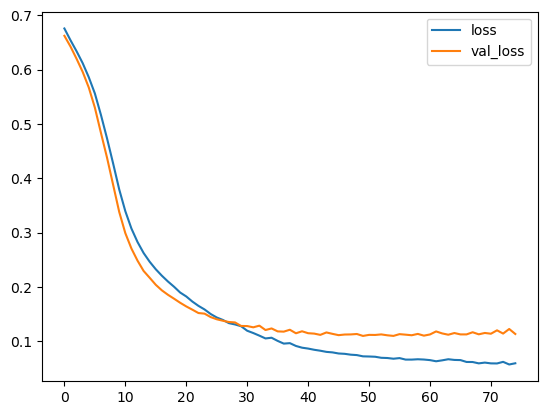

In [43]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Example Three: Adding in DropOut Layers

In [44]:
from tensorflow.keras.layers import Dropout

In [56]:
#building a model with drouput layer
model_ = Sequential()
model_.add(Dense(units=30,activation='relu'))
model_.add(Dropout(0.5))

model_.add(Dense(units=15,activation='relu'))
model_.add(Dropout(0.5))

model_.add(Dense(units=1,activation='sigmoid'))
model_.compile(loss='binary_crossentropy', optimizer='adam')

In [57]:
#now the model has dropouts , and earlystopping as well
model_.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/600


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.6924 - val_loss: 0.6849
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6861 - val_loss: 0.6779
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6677 - val_loss: 0.6639
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6617 - val_loss: 0.6499
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6504 - val_loss: 0.6311
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6324 - val_loss: 0.6072
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5921 - val_loss: 0.5713
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5957 - val_loss: 0.5398
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5687 - val_loss: 0.5152
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5365 - val_loss: 0.4946
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5376 - val_loss: 0.4720
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5

<Axes: >

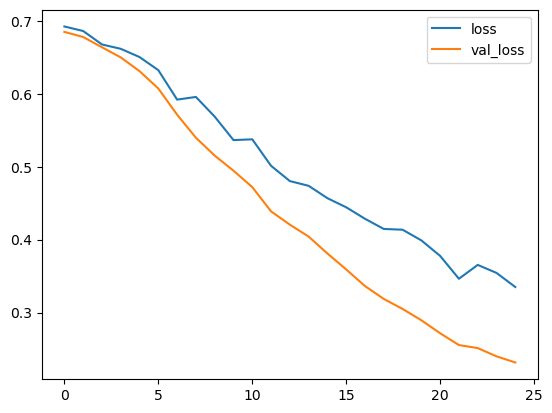

In [58]:
model_loss = pd.DataFrame(model_.history.history)
model_loss.plot()

# Model Evaluation

In [69]:
predictions = model_.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [65]:
from sklearn.metrics import classification_report, confusion_matrix

In [70]:
predictions

array([[0.8877973 ],
       [0.8851898 ],
       [0.8690462 ],
       [0.32000908],
       [0.96347034],
       [0.9339789 ],
       [0.97094005],
       [0.10654457],
       [0.9062664 ],
       [0.9452664 ],
       [0.22700526],
       [0.9336476 ],
       [0.90818906],
       [0.9428544 ],
       [0.21952401],
       [0.98879725],
       [0.75138414],
       [0.9359759 ],
       [0.1983755 ],
       [0.5673436 ],
       [0.92882764],
       [0.97856927],
       [0.8281867 ],
       [0.94250727],
       [0.25337157],
       [0.90220404],
       [0.281174  ],
       [0.9620376 ],
       [0.2206234 ],
       [0.30850673],
       [0.46503964],
       [0.2936889 ],
       [0.4584123 ],
       [0.59169185],
       [0.89637226],
       [0.9139939 ],
       [0.37805307],
       [0.3415161 ],
       [0.21849442],
       [0.16870305],
       [0.2723634 ],
       [0.90284437],
       [0.96525985],
       [0.47023097],
       [0.983182  ],
       [0.9342159 ],
       [0.19859515],
       [0.600

In [68]:
y_test

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0])

In [72]:
#converting the predictions into whole number 
predictions = (predictions > 0.5).astype(int)

In [73]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        55
           1       0.97      0.95      0.96        88

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [74]:
print(confusion_matrix(y_test,predictions))

[[52  3]
 [ 4 84]]
